In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
train = pd.read_csv('/kaggle/input/titanic/train.csv')
test = pd.read_csv('/kaggle/input/titanic/test.csv')
submission = pd.read_csv('/kaggle/input/titanic/gender_submission.csv')


In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
test.tail(2)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [5]:
train.shape, test.shape, submission.shape

((891, 12), (418, 11), (418, 2))

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


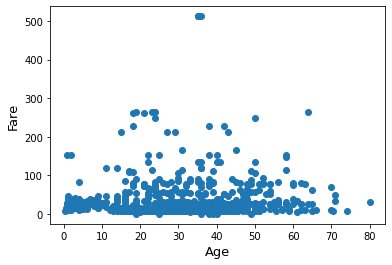

In [7]:
# EDA (Exploratory Data Analysis) 탐색적 데이터 분석 -> 시각화
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.scatter(x = train['Age'], y = train['Fare'])
plt.ylabel('Fare', fontsize=13)
plt.xlabel('Age', fontsize=13)
plt.show()

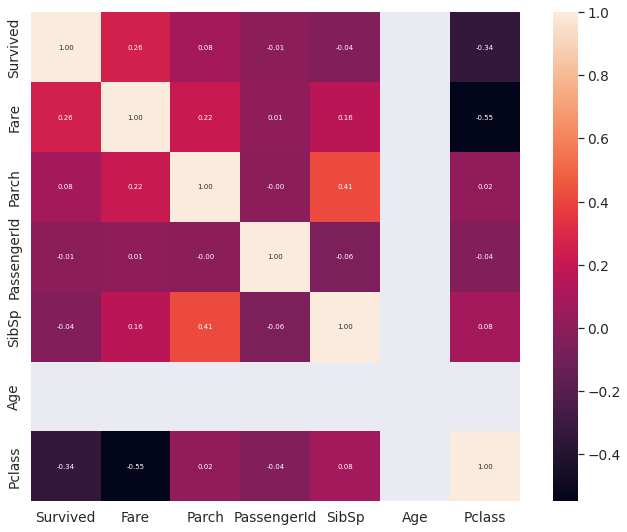

In [8]:
import seaborn as sns
# saleprice correlation matrix
corrmat = train.corr()
# corr_num = 15 #number of variables for heatmap
corr_num = 10
cols_corr = corrmat.nlargest(corr_num, 'Survived')['Survived'].index
corr_mat_sales = np.corrcoef(train[cols_corr].values.T)
sns.set(font_scale=1.25)
f, ax = plt.subplots(figsize=(12, 9))
hm = sns.heatmap(corr_mat_sales, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 7}, yticklabels=cols_corr.values, xticklabels=cols_corr.values)
plt.show()

<AxesSubplot:>

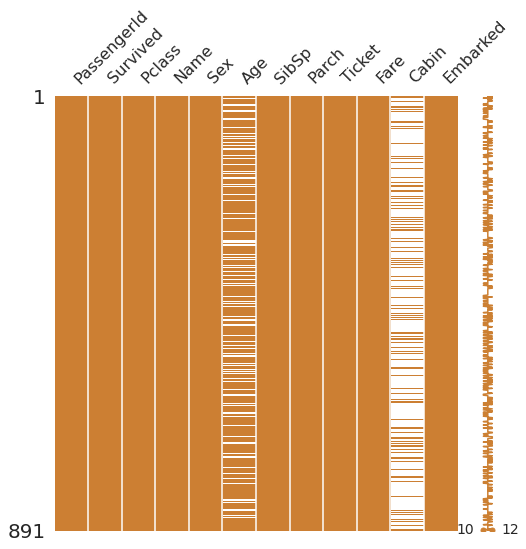

In [9]:
import missingno as msno
msno.matrix(df=train, figsize=(8,8), color=(0.8, 0.5, 0.2))

In [10]:
# train의 결측값 (빈 값) 확인
train.isnull().sum(), test.isnull().sum()

(PassengerId      0
 Survived         0
 Pclass           0
 Name             0
 Sex              0
 Age            177
 SibSp            0
 Parch            0
 Ticket           0
 Fare             0
 Cabin          687
 Embarked         2
 dtype: int64,
 PassengerId      0
 Pclass           0
 Name             0
 Sex              0
 Age             86
 SibSp            0
 Parch            0
 Ticket           0
 Fare             1
 Cabin          327
 Embarked         0
 dtype: int64)

In [11]:
print(round(train.isnull().sum() / len(train) * 100, 2).sort_values(ascending=False)[:5])
print(round(test.isnull().sum() / len(test) * 100, 2).sort_values(ascending=False)[:5])

Cabin          77.10
Age            19.87
Embarked        0.22
PassengerId     0.00
Survived        0.00
dtype: float64
Cabin          78.23
Age            20.57
Fare            0.24
PassengerId     0.00
Pclass          0.00
dtype: float64


In [12]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [13]:
train['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [14]:
train['Age'].mean()
# train['Age'] = train['Age'].fillna(30)
train['Age'] = train['Age'].fillna(train['Age'].mean())
test['Age'] = test['Age'].fillna(test['Age'].mean())

In [15]:
print(round(train.isnull().sum() / len(train) * 100, 2).sort_values(ascending=False)[:5])

Cabin          77.10
Embarked        0.22
PassengerId     0.00
Survived        0.00
Pclass          0.00
dtype: float64


In [16]:
train['Cabin'].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [17]:
train = train.drop(['Cabin'], axis=1)
test = test.drop(['Cabin'], axis=1)

In [18]:
print(round(train.isnull().sum() / len(train) * 100, 2).sort_values(ascending=False)[:5])

Embarked       0.22
PassengerId    0.00
Survived       0.00
Pclass         0.00
Name           0.00
dtype: float64


In [19]:
train.groupby(['Embarked','Pclass'])['Fare'].mean()

Embarked  Pclass
C         1         104.718529
          2          25.358335
          3          11.214083
Q         1          90.000000
          2          12.350000
          3          11.183393
S         1          70.364862
          2          20.327439
          3          14.644083
Name: Fare, dtype: float64

In [20]:
train['Embarked'].value_counts()

S    644
C    168
Q     77
Name: Embarked, dtype: int64

In [21]:
# train['Embarked'] = train['Embarked'].fillna('S')
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])

In [22]:
round(test.isnull().sum() / len(test) * 100, 2).sort_values(ascending=False)[:5]

Fare           0.24
PassengerId    0.00
Pclass         0.00
Name           0.00
Sex            0.00
dtype: float64

In [23]:
train['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [24]:
test['Fare'] = test['Fare'].fillna(32)

In [25]:
round(test.isnull().sum() / len(test) * 100, 2).sort_values(ascending=False)[:5]

PassengerId    0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
dtype: float64

In [26]:
train.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S


In [27]:
train['Sex'].value_counts()

male      577
female    314
Name: Sex, dtype: int64

In [28]:
train['Sex'] = train['Sex'].replace('male', 0)
train['Sex'] = train['Sex'].replace('female', 1)
train['Sex'].head(3)
test['Sex'] = test['Sex'].replace('male', 0)
test['Sex'] = test['Sex'].replace('female', 1)

In [29]:
train.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,S


In [30]:
train.shape, train['Name'].nunique(), train['Ticket'].nunique()

((891, 11), 891, 681)

In [31]:
train = train.drop(['Name', 'Ticket'],axis=1)
test = test.drop(['Name', 'Ticket'],axis=1)
train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,0,22.0,1,0,7.2500,S
1,2,1,1,1,38.0,1,0,71.2833,C
2,3,1,3,1,26.0,0,0,7.9250,S
3,4,1,1,1,35.0,1,0,53.1000,S
4,5,0,3,0,35.0,0,0,8.0500,S


In [32]:
from sklearn.preprocessing import LabelEncoder
lbl = LabelEncoder()

train['Embarked'] = lbl.fit_transform(list(train['Embarked'].values))
test['Embarked'] = lbl.fit_transform(list(test['Embarked'].values))
train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,0,22.0,1,0,7.2500,2
1,2,1,1,1,38.0,1,0,71.2833,0
2,3,1,3,1,26.0,0,0,7.9250,2
3,4,1,1,1,35.0,1,0,53.1000,2
4,5,0,3,0,35.0,0,0,8.0500,2


In [33]:
train.dtypes, test.dtypes

(PassengerId      int64
 Survived         int64
 Pclass           int64
 Sex              int64
 Age            float64
 SibSp            int64
 Parch            int64
 Fare           float64
 Embarked         int64
 dtype: object,
 PassengerId      int64
 Pclass           int64
 Sex              int64
 Age            float64
 SibSp            int64
 Parch            int64
 Fare           float64
 Embarked         int64
 dtype: object)

In [34]:
X = train.drop(['Survived'], axis=1)
X.head(3)

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,3,0,22.0,1,0,7.2500,2
1,2,1,1,38.0,1,0,71.2833,0
2,3,3,1,26.0,0,0,7.9250,2


In [35]:
y = train['Survived']
y.head(3)

0    0
1    1
2    1
Name: Survived, dtype: int64

In [36]:
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(X,y,random_state=0, test_size=0.3)
X_train.shape, X_valid.shape, y_train.shape, y_valid.shape

((623, 8), (268, 8), (623,), (268,))

In [37]:
X_train.head(3)

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
857,858,1,0,51.0,0,0,26.5500,2
52,53,1,1,49.0,1,0,76.7292,0
386,387,3,0,1.0,5,2,46.9000,2


In [38]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn import svm
from sklearn.linear_model import RidgeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from catboost import CatBoostClassifier

model = LGBMClassifier() # 0.994/0.813
# model = XGBClassifier() # 1/0.802
# model = svm.SVC() # 0.629/0.660
# model = RidgeClassifier() # 0.799/0.791
# model = LogisticRegression(random_state=0) # 0.799/0.794
# model = DecisionTreeClassifier() # 1.0/0.742
# model = RandomForestClassifier(random_state=0) # 1.0/0.832
# model = AdaBoostClassifier() # 0.844/0.810
# model = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, max_depth=1, random_state=0) # 0.880/0.813
# model = CatBoostClassifier() # 0.920/0.832
model.fit(X_train, y_train)
pred_train = model.predict(X_train)
print((pred_train == y_train).mean()) # 학습 정확도
pred_valid = model.predict(X_valid)
print((pred_valid == y_valid).mean()) # 검증 정확도

0.9919743178170144
0.7985074626865671


In [39]:
pred_test = model.predict(test)

In [40]:
submission.head(3)

,PassengerId,Survived
0,892,0
1,893,1
2,894,0


In [41]:
submission['Survived'] = pred_test
submission.head(3)

,PassengerId,Survived
0,892,0
1,893,0
2,894,0


In [42]:
submission.to_csv('submission1.csv', index=False)

In [43]:
# submission.to_excel('submission2.excel', index=False, engine='cp949')